In [1]:
from openai import OpenAI
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import os

load_dotenv()

client = OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY"),
)

In [2]:
filepath = "../../data/hannah_semantic_exploration_df.csv"

df = pd.read_csv(filepath)

df.head()

,Unnamed: 0,selftext,created_utc,title,subreddit,subreddit_id,retrieved_on,post_id,tags,tag_count
0,0,"Tldr Hello, i just wanna say that if you cant ...",1727975425,I hate my mom so fucking much. She is the root...,SuicideWatch,t5_2qpzs,1727975440,t3_1fvcrw3,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6
1,1,"I am 22 F, I have had multiple self-harm attem...",1727571222,Thinking about ending it all.,SuicideWatch,t5_2qpzs,1727571238,t3_1frsnkc,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6
2,2,This is a vent and trauma dump lol.\n\nEver si...,1718775564,I hate living and have always felt like I was ...,SuicideWatch,t5_2qpzs,1718775579,t3_1djbnvd,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6
3,3,I’m a 19 year old woman who’s been having suic...,1736380213,Man I’m done,SuicideWatch,t5_2qpzs,1736380227,t3_1hwywkd,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6
4,4,This is kinda long and I’m sorry. \n\nI’m actu...,1727919172,I’m actually losing it. Please help me,SuicideWatch,t5_2qpzs,1727919188,t3_1fuwjws,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6


In [5]:
def get_embeddings_batch(texts, batch_size=100):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        response = client.embeddings.create(
            input=batch,
            model="text-embedding-3-small"
        )

        batch_embeddings = [r.embedding for r in response.data]
        embeddings.extend(batch_embeddings)

        print(f"Processed {i}/{len(texts)}.")
    
    return np.array(embeddings)


combined = df["title"] + " | " + df["selftext"]

embeddings = get_embeddings_batch(combined)
np.save("../../data/hannah_embeddings.npy", embeddings)

Processed 0/1583.
Processed 100/1583.
Processed 200/1583.
Processed 300/1583.
Processed 400/1583.
Processed 500/1583.
Processed 600/1583.
Processed 700/1583.
Processed 800/1583.
Processed 900/1583.
Processed 1000/1583.
Processed 1100/1583.
Processed 1200/1583.
Processed 1300/1583.
Processed 1400/1583.
Processed 1500/1583.


In [8]:
embeddings = np.load("../../data/hannah_embeddings.npy")

print(f"Embeddings shape: {embeddings.shape}")   # should be (1583, 1536)
print(f"DataFrame rows:   {len(df)}")

assert len(embeddings) == len(df), "Row count mismatch — embeddings and df are out of sync"

df["embedding"] = list(embeddings)

print(f"\nSample embedding (first 5 dims): {df['embedding'].iloc[0][:5]}")

df.head()

Embeddings shape: (1583, 1536)
DataFrame rows:   1583

Sample embedding (first 5 dims): [ 0.01605225  0.00026202 -0.01395416  0.06738281 -0.00680542]


,Unnamed: 0,selftext,created_utc,title,subreddit,subreddit_id,retrieved_on,post_id,tags,tag_count,embedding
0,0,"Tldr Hello, i just wanna say that if you cant ...",1727975425,I hate my mom so fucking much. She is the root...,SuicideWatch,t5_2qpzs,1727975440,t3_1fvcrw3,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6,"[0.01605224609375, 0.0002620220184326172, -0.0..."
1,1,"I am 22 F, I have had multiple self-harm attem...",1727571222,Thinking about ending it all.,SuicideWatch,t5_2qpzs,1727571238,t3_1frsnkc,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6,"[0.04241943359375, -0.003536224365234375, 0.01..."
2,2,This is a vent and trauma dump lol.\n\nEver si...,1718775564,I hate living and have always felt like I was ...,SuicideWatch,t5_2qpzs,1718775579,t3_1djbnvd,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6,"[0.01293182373046875, -0.0048065185546875, 0.0..."
3,3,I’m a 19 year old woman who’s been having suic...,1736380213,Man I’m done,SuicideWatch,t5_2qpzs,1736380227,t3_1hwywkd,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6,"[0.03887939453125, 0.00444793701171875, 0.0085..."
4,4,This is kinda long and I’m sorry. \n\nI’m actu...,1727919172,I’m actually losing it. Please help me,SuicideWatch,t5_2qpzs,1727919188,t3_1fuwjws,"['age', 'female', 'selfharm', 'bullying', 'sa'...",6,"[0.01265716552734375, 0.0176849365234375, -0.0..."


In [17]:
import hdbscan
import umap
from sklearn.preprocessing import normalize

normalised_embeddings = normalize(embeddings)

reducer = umap.UMAP(
    n_components=10,
    n_neighbors=10,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_10d = reducer.fit_transform(normalised_embeddings)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,   # want clusters of 20-60 posts
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom'
)
clusterer.fit(embeddings_10d)

e:\Documents\Code\mentalhealth_ml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,min_cluster_size,10
,min_samples,5
,cluster_selection_epsilon,0.0
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


Clusters: 3
Noise:    0 (0.0%)

cluster
0      18
1      50
2    1515


e:\Documents\Code\mentalhealth_ml\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


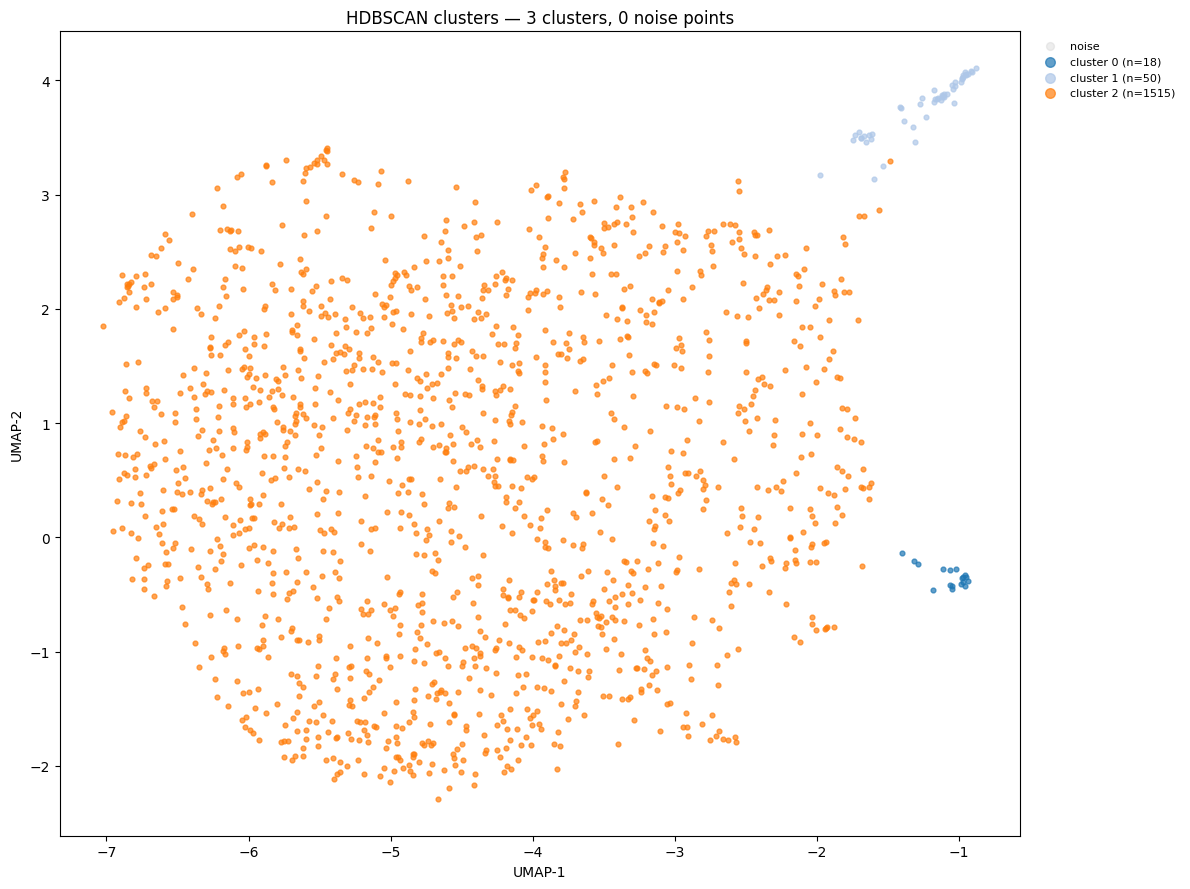

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Attach labels back to df
df["cluster"]      = clusterer.labels_
df["cluster_prob"] = clusterer.probabilities_

n_clusters = df["cluster"].nunique() - (1 if -1 in df["cluster"].values else 0)
n_noise    = (df["cluster"] == -1).sum()

print(f"Clusters: {n_clusters}")
print(f"Noise:    {n_noise} ({n_noise/len(df):.1%})")
print()
print(df["cluster"].value_counts().sort_index().to_string())

# ── 2D UMAP for visualisation (separate from 10D used for clustering) ─────────
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
coords = reducer_2d.fit_transform(normalised_embeddings)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

# Noise points in grey first
noise_mask = df["cluster"] == -1
ax.scatter(
    coords[noise_mask, 0], coords[noise_mask, 1],
    c="lightgrey", s=8, alpha=0.4, label="noise", zorder=1
)

# Colour each cluster distinctly
colors = cm.tab20.colors + cm.tab20b.colors  # 40 distinct colours
for cid in sorted(df.loc[~noise_mask, "cluster"].unique()):
    mask = df["cluster"] == cid
    color = colors[cid % len(colors)]
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[color], s=12, alpha=0.7, label=f"cluster {cid} (n={mask.sum()})", zorder=2
    )

ax.set_title(f"HDBSCAN clusters — {n_clusters} clusters, {n_noise} noise points")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(
    loc="upper left", bbox_to_anchor=(1.01, 1),
    fontsize=8, markerscale=2, frameon=False
)
plt.tight_layout()
plt.show()

# KMeans Clustering
Target ~50 posts per cluster → ~31 clusters for 1583 posts. Silhouette search over K=15–50 to find optimal K.

K= 15:  silhouette=0.3032  avg cluster size=106
K= 16:  silhouette=0.3107  avg cluster size=99
K= 17:  silhouette=0.3014  avg cluster size=93
K= 18:  silhouette=0.3037  avg cluster size=88
K= 19:  silhouette=0.2849  avg cluster size=83
K= 20:  silhouette=0.2954  avg cluster size=79
K= 21:  silhouette=0.3042  avg cluster size=75
K= 22:  silhouette=0.2868  avg cluster size=72
K= 23:  silhouette=0.3240  avg cluster size=69
K= 24:  silhouette=0.2968  avg cluster size=66
K= 25:  silhouette=0.3020  avg cluster size=63
K= 26:  silhouette=0.3142  avg cluster size=61
K= 27:  silhouette=0.3113  avg cluster size=59
K= 28:  silhouette=0.3074  avg cluster size=57
K= 29:  silhouette=0.3255  avg cluster size=55
K= 30:  silhouette=0.3163  avg cluster size=53
K= 31:  silhouette=0.2973  avg cluster size=51
K= 32:  silhouette=0.3243  avg cluster size=49
K= 33:  silhouette=0.3173  avg cluster size=48
K= 34:  silhouette=0.2984  avg cluster size=47
K= 35:  silhouette=0.3022  avg cluster size=45
K= 36:  silh

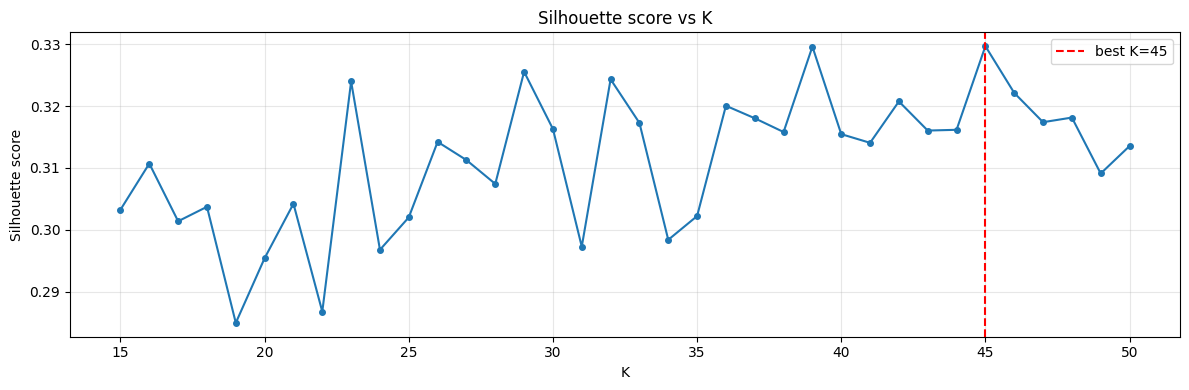

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ~50 posts/cluster with 1583 posts → K≈31, search either side
k_range = range(15, 51)
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings_10d)
    score = silhouette_score(embeddings_10d, labels, sample_size=500, random_state=42)
    silhouette_scores.append(score)
    print(f"K={k:>3}:  silhouette={score:.4f}  avg cluster size={len(df)/k:.0f}")

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest K: {best_k}  (silhouette={max(silhouette_scores):.4f})")

plt.figure(figsize=(12, 4))
plt.plot(list(k_range), silhouette_scores, marker='o', markersize=4)
plt.axvline(best_k, color='red', linestyle='--', label=f'best K={best_k}')
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

K=45  —  cluster size distribution:
cluster
0     44
1     23
2     20
3     29
4     65
5     28
6     16
7     70
8     50
9     79
10    51
11    38
12    20
13    49
14    26
15    30
16    50
17    21
18    18
19    40
20    40
21    23
22    29
23    26
24    43
25    37
26    43
27    40
28    11
29    20
30    35
31    42
32    37
33    38
34    25
35    23
36    71
37    29
38    16
39    71
40    28
41    19
42    26
43    22
44    22


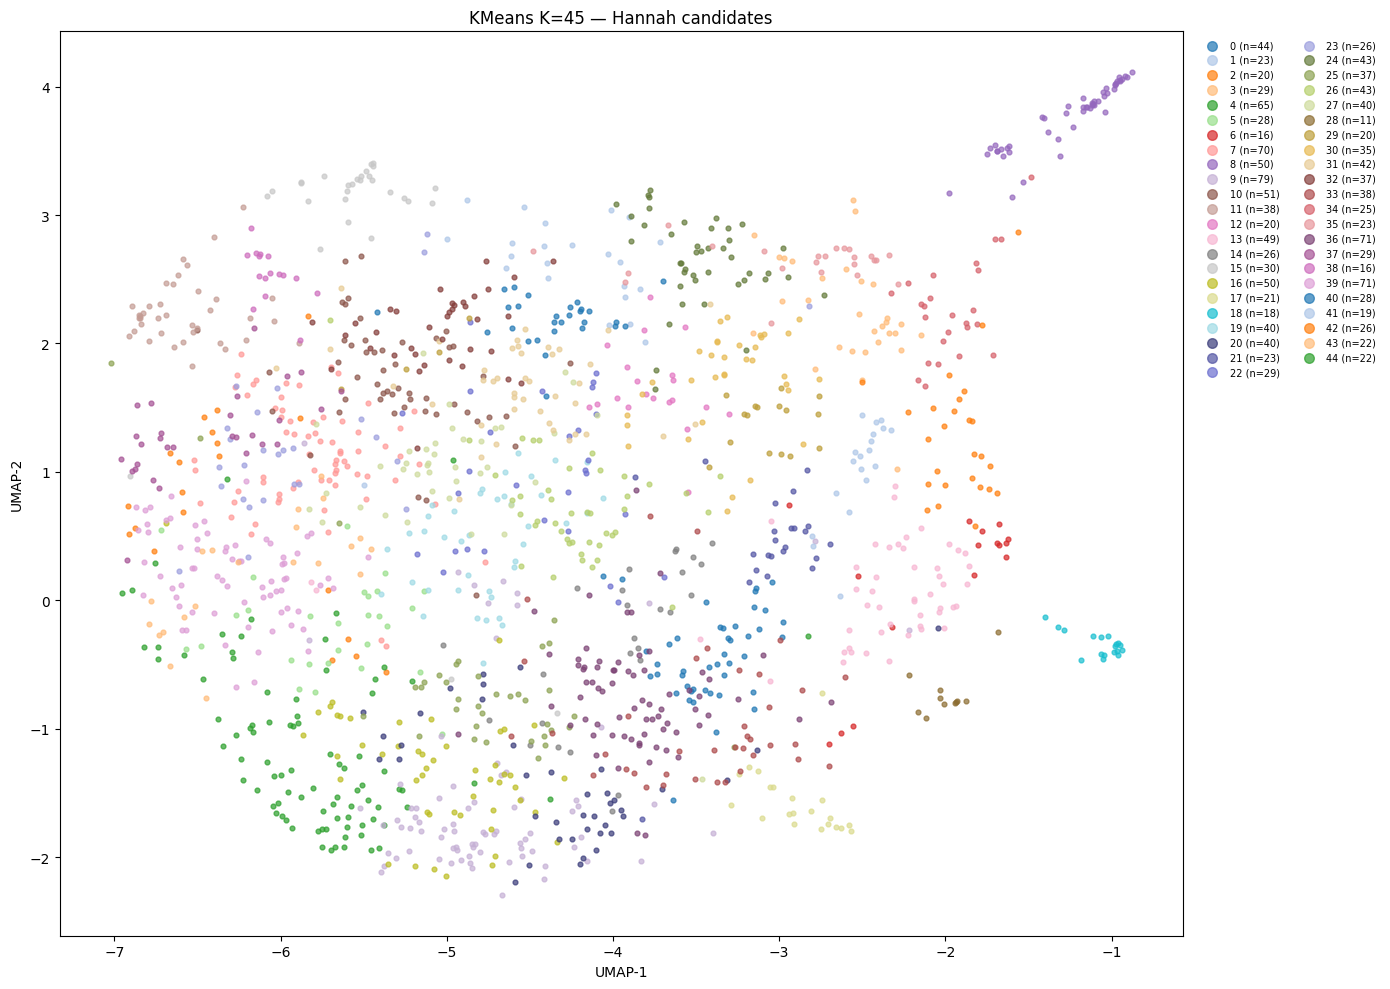

In [20]:
# ── Final KMeans + visualisation ──────────────────────────────────────────────
# Change best_k manually here if you prefer a different K
K = best_k

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster"]      = kmeans.fit_predict(embeddings_10d)
df["cluster_prob"] = 1.0  # KMeans has no soft assignment — all points are "in"

print(f"K={K}  —  cluster size distribution:")
print(df["cluster"].value_counts().sort_index().to_string())

# Reuse coords from the 2D UMAP already computed above
fig, ax = plt.subplots(figsize=(14, 10))
colors = cm.tab20.colors + cm.tab20b.colors

for cid in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cid
    ax.scatter(
        coords[mask.values, 0], coords[mask.values, 1],
        c=[colors[cid % len(colors)]], s=12, alpha=0.7,
        label=f"{cid} (n={mask.sum()})"
    )

ax.set_title(f"KMeans K={K} — Hannah candidates")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7, markerscale=2, frameon=False, ncol=2)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

def read_cluster(cluster_id, n=5):
    mask      = df["cluster"] == cluster_id
    cluster_df = df[mask].copy()
    cluster_embs = normalised_embeddings[mask.values]

    centroid = cluster_embs.mean(axis=0)
    sims     = cosine_similarity([centroid], cluster_embs)[0]
    cluster_df["sim_to_centroid"] = sims

    top = cluster_df.nlargest(n, "sim_to_centroid")

    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}  —  {mask.sum()} posts")
    print("="*70)
    for _, row in top.iterrows():
        print(f"\n  [sim={row['sim_to_centroid']:.3f}]  {row['title']}")
        print(f"  {row['selftext'][:350].strip()}")
        print("  ---")

# Print all clusters — comment out and call read_cluster(n) for a single one
for cid in sorted(df["cluster"].unique()):
    read_cluster(cid)


CLUSTER 0  —  44 posts

  [sim=0.888]  am ready to go
  I feel like everything in my life has gone wrong in every way and i am so tired. i just turned 18 2 weeks ago and im over everything. i cant keep relationships because i “lack an emotional connection” that is never brought up until we break up. ive lost nearly all my friends. all my best friends have best friends, im never anyones first choice its
  ---

  [sim=0.886]  what’s wrong with me. 
  i think i’m fucked up in the head. 

my whole life, it’s been me, my mom and one of her boyfriends. if doesn’t matter who she gets with, they’re all abusive. physically. mentally. psychologically. even sexually. if i can see it as a 14 year old girl, why can’t she see that as a 33 year old woman. i don’t understand why she keeps putting us both in
  ---

  [sim=0.871]  can’t take it 
  i’ve struggled with anxiety and depression since i was a kid and i’m 17 now and thought i was healing and everything has suddenly gotten so much worse. my be

In [3]:
posts_6tags = df[df["tag_count"] == 5].reset_index(drop=True)

print(f"{len(posts_6tags)} posts with all 6 tags\n")
for i, row in posts_6tags.iterrows():
    print(f"{'='*70}")
    print(f"[{i+1}/{len(posts_6tags)}]  {row['post_id']}")
    print(f"Title: {row['title']}")
    print(f"Tags:  {row['tags']}")
    print()
    print(row['selftext'])
    print()

274 posts with all 6 tags

[1/274]  t3_1h2h9cn
Title: How long does it take to die if you stop drinking water? 
Tags:  ['age', 'female', 'selfharm', 'bullying', 'suicidal']

I'm on day 2 I'm pretty much just done for life but I'm wondering how long I gotta put up with this 😂 I'll talk about myself a bit I don't think my story is that sad I think I've just been dealt a bad hand mentally and it makes it all 10x harder to deal with. So from a young age I was always different, I'm probably autistic if I had to guess. My parents got divorced when I was 7 Both cheated My dad was a truck driver and was never home and when he was he neglected me and my sister basically treating us like we weren't really there. Mom sadly was the same I had to see them get into a fist fight when I was a kid and the cops got called that prob did a lot of damage to me mentally if I had to guess. Later my mom married the person she was cheating on my dad with.. Me and my mom were making cupcakes one day and my dad 

In [4]:
posts_6tags.to_csv("../../data/hannah_raw_posts.csv")